### Notebook 3: Exploratory Data Analysis

In this notebook, we deploy the analysis toolkit developed in Notebook 2 to perform univariate exploratory data analysis to analyze the 13 clinical determinants of mortality in breast cancer patients.

**For numerical factors**: A boxplot is utilized to visualize the distribution of the variable against the patients' survival status, validated using Welch's T-Test.

**For categorical factors**: A 3-panel analysis dashboard is generated to evaluate the factor from multiple angles:
1. Absolute Outcomes (Bar Chart): Displays the raw volume and proportional mortality rates across groups, validated by a Chi-Square Test.
  2. Mortality Velocity (Boxplot): Isolates deceased patients to evaluate if a specific category accelerates the timeline to death, validated by ANOVA or a Welch's T-Test.
  3. Survival Trajectory (Kaplan-Meier Curve): Models the long-term probability of survival over time across the different groups, validated by a Multivariate Log-Rank Test.

In [16]:
import pandas as pd

# Import the analysis tools developed in Notebook 2
import analysis_tools as at

In [17]:
# Import and load the cleaned dataset
df = pd.read_csv('../data/processed/data_clean.csv')

#### **1. Age** (Numerical factor)

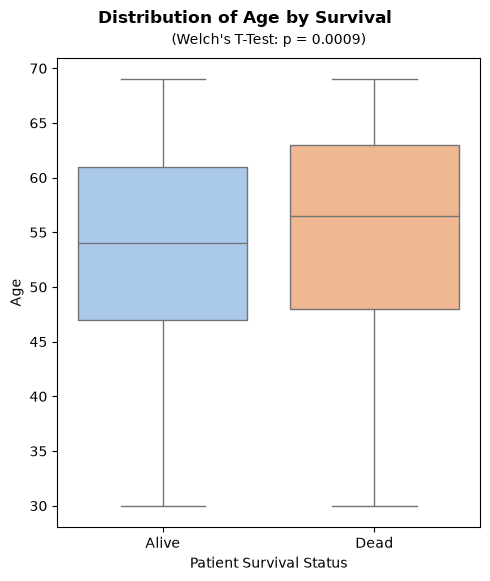

In [18]:
at.plot_box_numerical_with_stats('Age', df)

**Results Interpretation:**

The distribution reveals a clear upward shift in age for the deceased cohort. While both groups share a similar overall range (spanning from roughly 30 to 69 years), the deceased patients exhibit a higher median age (~ 56.5 years) compared to the surviving cohort (~ 54 years). Furthermore, the entire interquartile range sits higher for the deceased group.

This visual trend is validated by the Welch's T-Test, which yielded a p-value of 0.0009. This p-value validated that the age difference between the two cohorts is statistically different and not a result of random sampling variation.

Therefore, patient age is a highly statistically significant prognostic factor within this dataset. Older age at the time of diagnosis correlates strongly with an increased likelihood of mortality.


#### **2. Tumor Size** (Numerical factor)

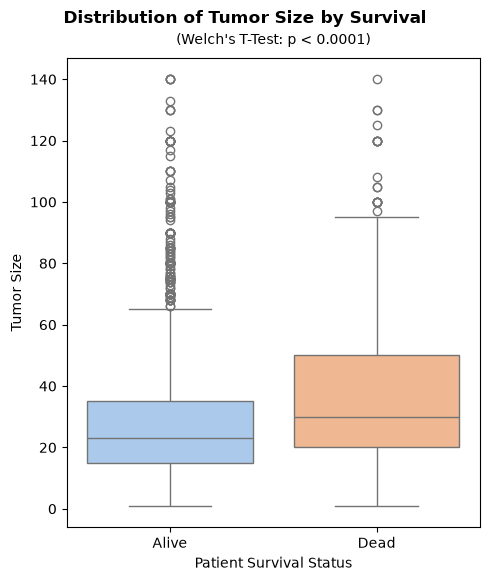

In [19]:
at.plot_box_numerical_with_stats('Tumor Size', df)

**Results Interpretation:**

The distribution reveals a clear upward shift in tumor size for the deceased cohort. While both groups present with a significant number of extreme outliers (reaching up to 140 mm), their central tendencies differ distinctly. The deceased patients exhibit a larger overall range (spanning from roughly 1 mm to 90 mm) and a higher median (~ 30 mm) compared to the surviving cohort (overall range of 1 mm to 65 mm, median of ~ 22 mm). Furthermore, the entire interquartile range sits higher and wider for the deceased group.

This visual trend is validated by the Welch's T-Test, which yielded a p-value of lesser than 0.0001. This p-value validated that the difference of tumor size between the two cohorts is statistically different.

Therefore, tumor size is a highly statistically significant prognostic factor within this dataset. A larger tumor at the time of diagnosis correlates strongly with an increased likelihood of mortality.


#### **3. Regional Node Examined** (Numerical factor)

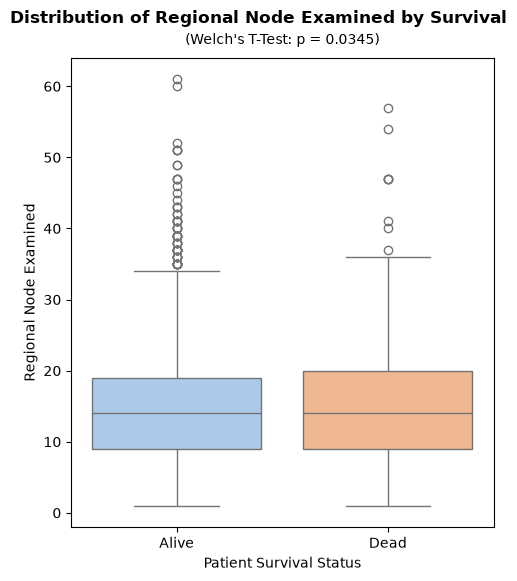

In [20]:
at.plot_box_numerical_with_stats('Regional Node Examined', df)

**Results Interpretation:**

Visually, the distribution of regional lymph nodes examined for both the surviving and deceased cohorts appear remarkably similar. Both groups share an identical median of approximately 14 nodes examined, and both present with a lower quartile resting near 9 nodes. However, an upward shift exists in the upper percentiles of the deceased cohort, with the 75th percentile extending slightly higher. The surviving cohort also presents with a higher volumn of extreme upper outliers.

Despite the strong similarities, this visual trend is validated by the Welch's T-Test, which yielded a p-value of 0.0345. This p-value validated that the difference of number of nodes examined between the two cohorts is statistically different. However, because the p-value is much closer to the 0.5 threshold, this represents a potentially weaker correlation.

Therefore, the number of examined lymph nodes is a statistically significant prognostic factor within this dataset. A higher number of lymph nodes examined at the time of diagnosis correlates moderately with an increased likelihood of mortality.

**Clinical Context:**

#### **4. Regional Node Positive** (Numerical factor)

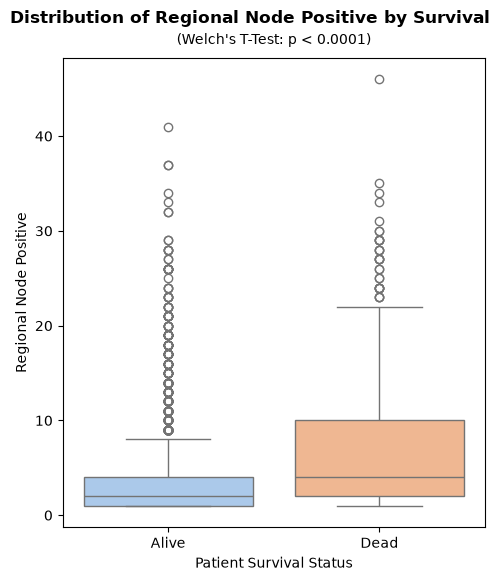

In [21]:
at.plot_box_numerical_with_stats('Regional Node Positive', df)

**Results Interpretation:**

The distribution reveals a clear upward shift in number of lymph nodes positive for cancer for the deceased cohort. While the surviving cohort is heavily clustered at the lower end, the deceased cohort exhibits notably wider and higher spread. The upper whisker of the deceased cohort extends much further compared to the surviving cohort.

This visual trend is validated by the Welch's T-Test, which yielded a p-value of lesser than 0.0001. This p-value validated that the difference in positive lymph node count between the two cohorts is statistically different and not a result of random sampling variation.

Therefore, the number of positive regional lymph nodes is a highly statistically significant prognostic factor within this dataset. Higher number of positive regional lymph nodes at the time of diagnosis correlates strongly with an increased likelihood of mortality.

**Clinical Context:**

#### **5. Race** (Categorical factor)

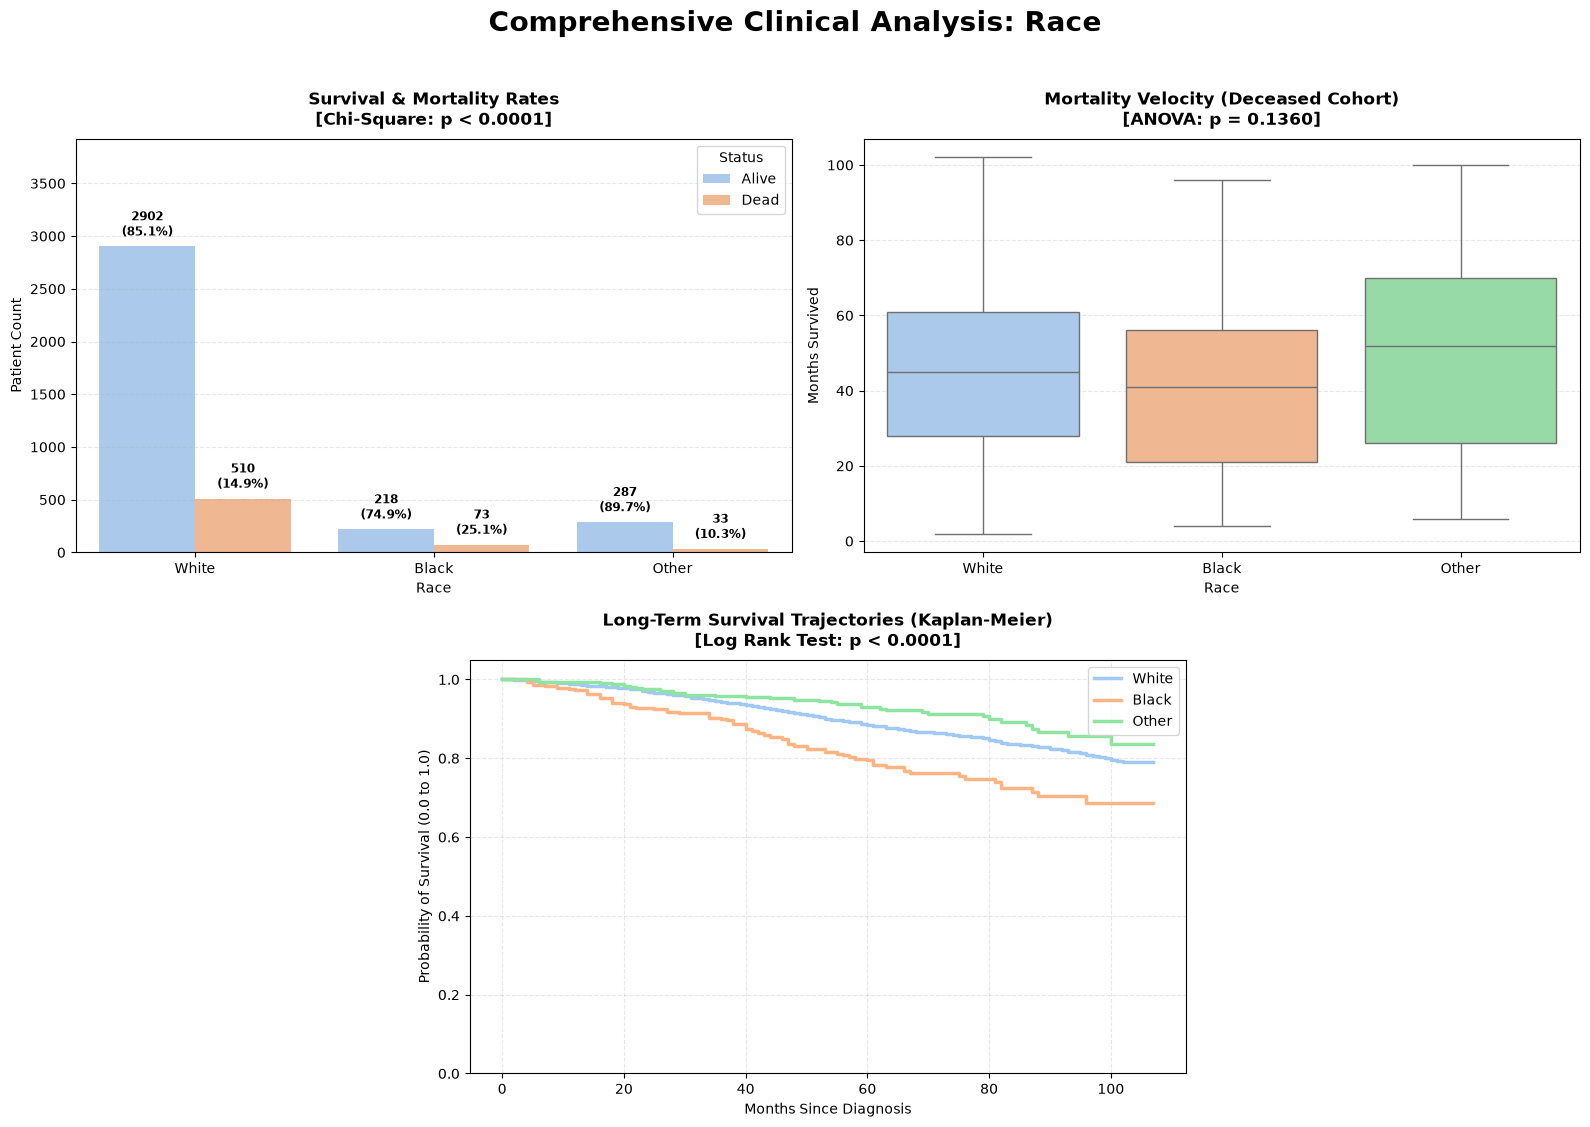

In [22]:
# Shorten the group name
df['Race'] = df['Race'].replace(
    'Other (American Indian/Ak Native, Asian/Pacific Islander)',
    'Other'
)

race_order = ['White', 'Black', 'Other']
at.plot_comprehensive_analysis_dashboard('Race', race_order, df)

**Results Interpretation:**

- Survival & Mortality Rates (p < 0.0001): There is a highly significant disparity in overall mortality rates. Black patients experience the highest mortality rate (25.1%).
- Survival Trajectories (p < 0.0001): The Kaplan-Meier curves reinforce this disparity. The long-term survival probability for Black patients diverges negatively very early in the timeline and remains substantially lower than other cohorts throughout the 100-month period.
- Mortality Velocity (p = 0.1360): The ANOVA test for the mortality velocity fails to reach statistical significance. This indicates that within the deceased cohort, the timeline from diagnosis to death is statistically similar across all races.

Therefore, race is a highly statistically significant prognostic factor for overall survival likelihood. However, once the disease becomes terminal, race does not significantly alter the velocity or timeline of mortality.

#### **6. Marital Status** (Categorical factor)

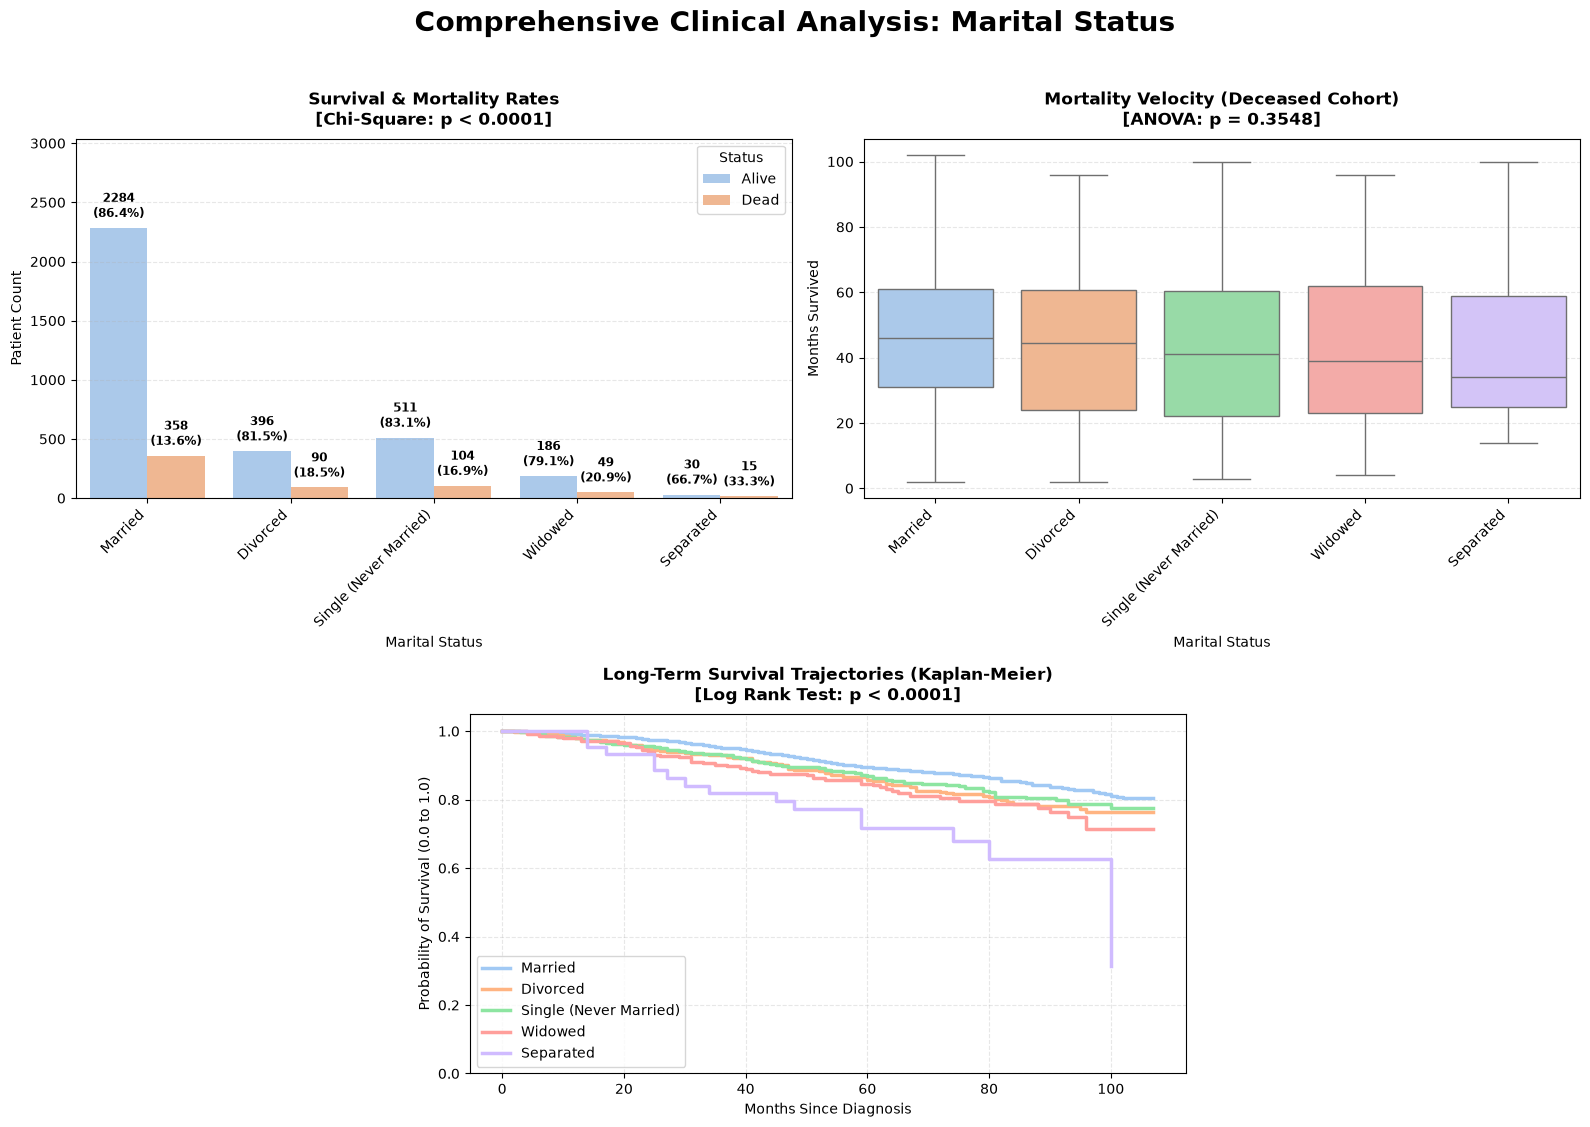

In [23]:
# Shorten the group name
df['Marital Status'] = df['Marital Status'].replace(
    'Married (Including Common Law)',
    'Married'
)

marital_order = ['Married', 'Divorced', 'Single (Never Married)', 'Widowed', 'Separated']
at.plot_comprehensive_analysis_dashboard('Marital Status', marital_order, df)

**Results Interpretation:**

- Survival & Mortality Rates (p < 0.0001): There is a highly significant disparity in overall mortality rates based on marital status. Married patients demonstrate the lowest mortality rate (13.6%), whereas patients who are separated exhibit the highest mortality rate (33.3%).
- Survival Trajectories (p < 0.0001): The Kaplan-Meier curves reinforce this disparity. The Married cohort consistently maintains the highest long-term survival probability. The Separated cohort drops sharply and remains significantly below all other groups throughout the observation period.
- Mortality Velocity (p = 0.3548): Similar to the racial cohort analysis, the ANOVA test for the mortality velocity fails to reach statistical significance. This indicates that within the deceased cohort, a patient's marital status does not statistically alter the timeline or velocity of their decline.

Therefore, marital status is a highly statistically significant prognostic factor for overall survival likelihood. However, once the disease becomes terminal, marital status does not significantly alter the velocity or timeline of mortality.

(Note: The 'Separated' cohort has a very small sample size, hence its results should be interpreted with slight caution.)

#### **7. T Stage** (Categorical factor)

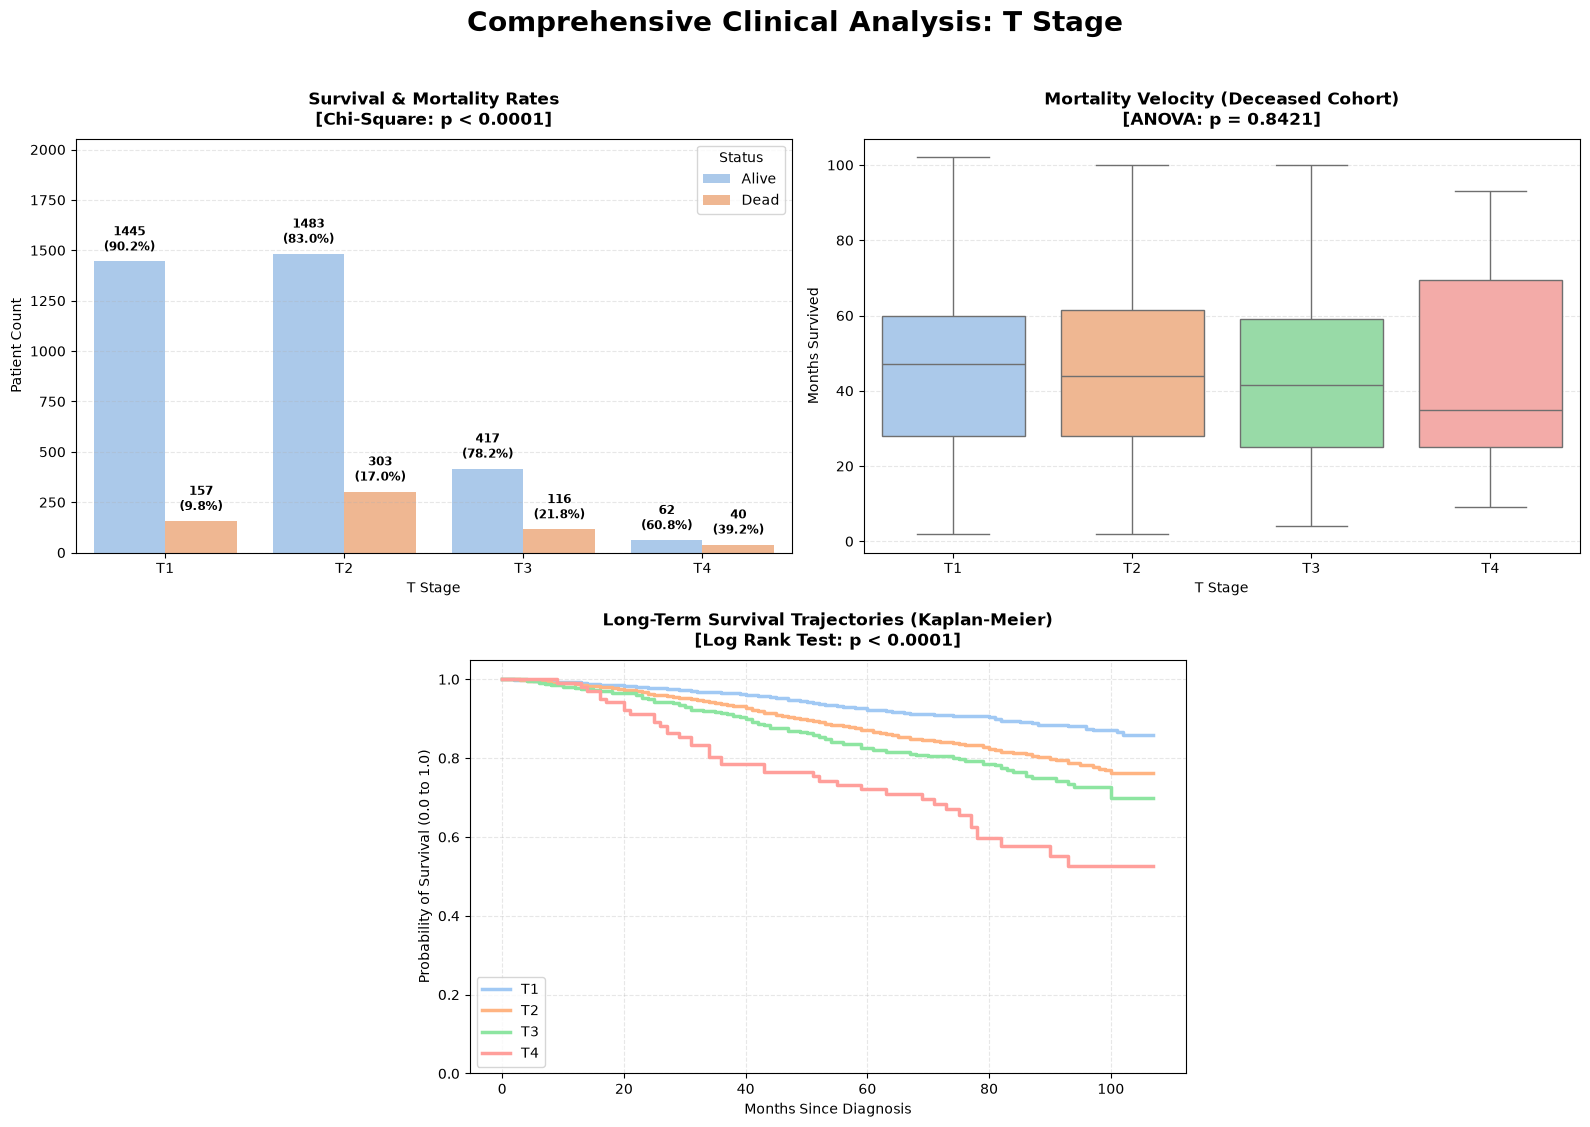

In [24]:
t_order = ['T1','T2','T3','T4']
at.plot_comprehensive_analysis_dashboard('T Stage', t_order, df)

**Results Interpretation:**

- Survival & Mortality Rates (p < 0.0001): There is a highly significant disparity in overall mortality rates based on T Stage. Patients at stage T1 (smallest tumor size) demonstrate the lowest mortality rate (9.8%), whereas patients at stage T4 (largest tumor size) exhibit the highest mortality rate (39.2%).
- Survival Trajectories (p < 0.0001): The Kaplan-Meier curves reinforce this disparity. The T1 cohort consistently maintains the highest long-term survival probability. The T4 cohort drops sharply and remains significantly below all other groups throughout the observation period.
- Mortality Velocity (p = 0.8421): Similarly, the ANOVA test for the mortality velocity fails to reach statistical significance. Although the median survival months of patients in stage T4 is visually lower (35 months) than the other cohorts, the high p-value indicates that within the deceased cohort, patients' T Stage does not statistically alter the timeline or velocity of their decline.

Therefore, T Stage is a highly statistically significant prognostic factor for overall survival likelihood, which is entirely consistent with our earlier analysis of continuous Tumor Size. However, once the disease becomes terminal, T Stage does not significantly alter the velocity or timeline of mortality.

(Note: The 'T4' cohort has a relatively small sample size, hence its results should be interpreted with slight caution.)

#### **8. N Stage** (Categorical factor)

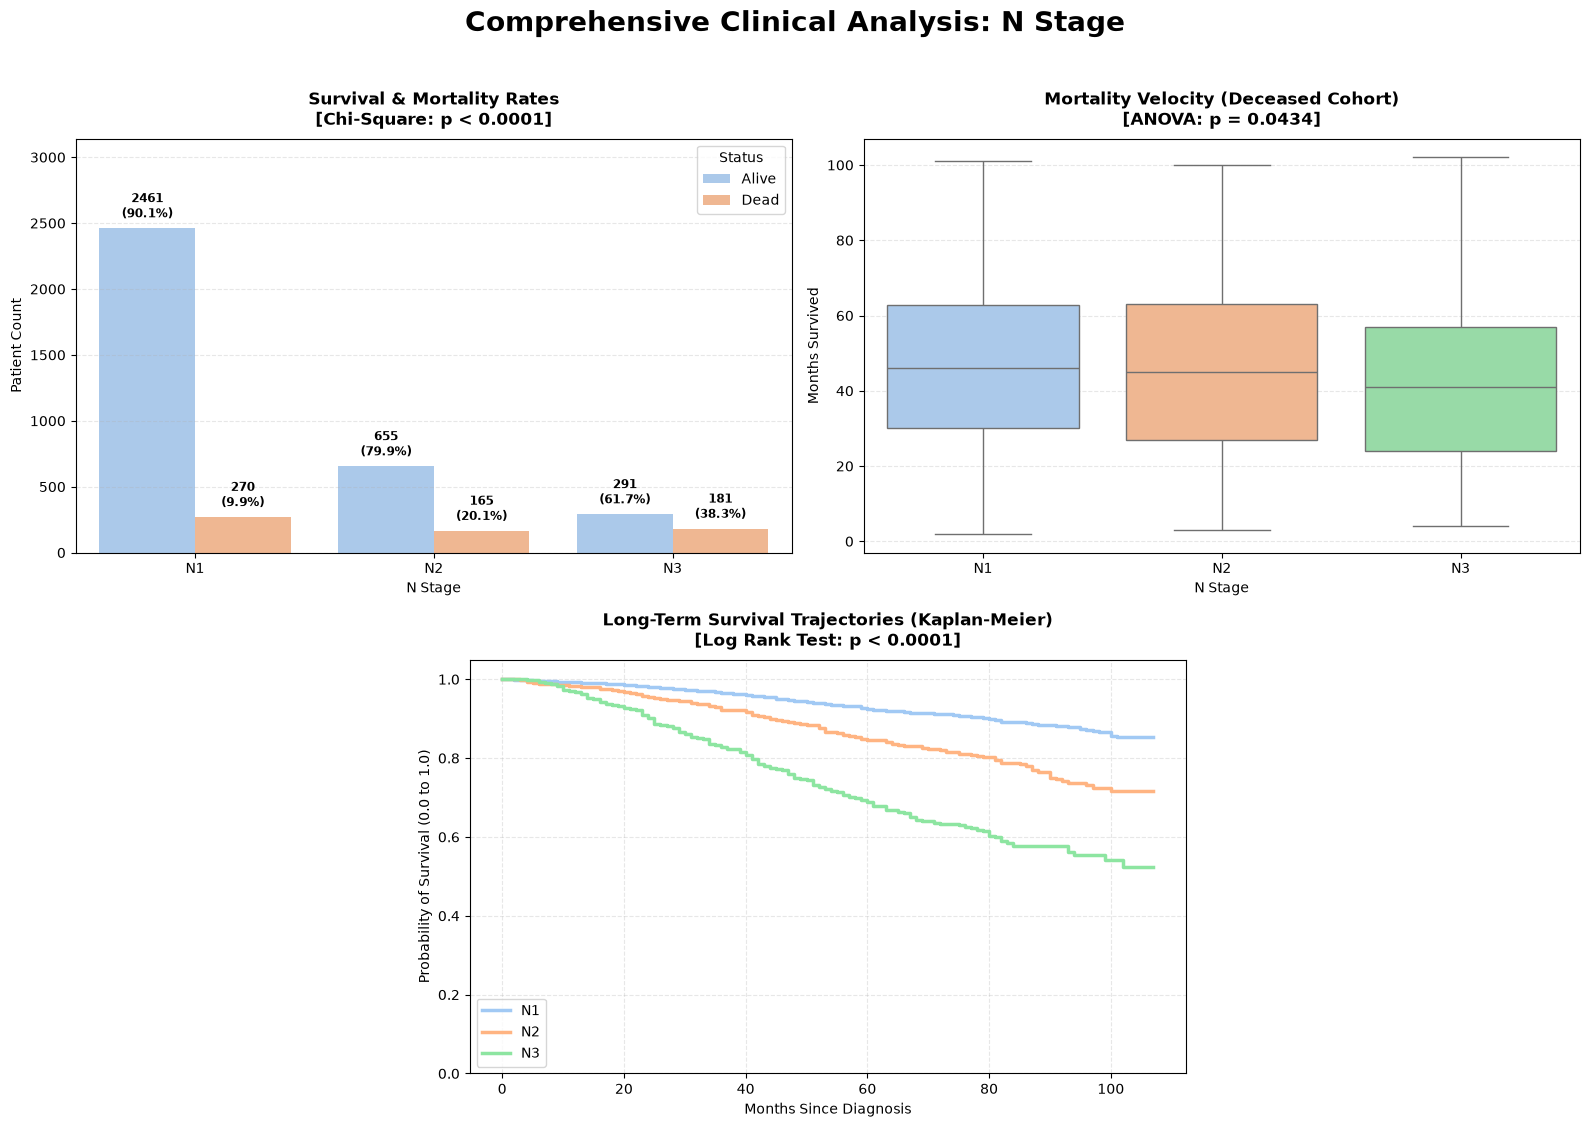

In [25]:
n_order = ['N1','N2','N3']
at.plot_comprehensive_analysis_dashboard('N Stage', n_order, df)

**Results Interpretation:**

- Survival & Mortality Rates (p < 0.0001): There is a highly significant, stepwise disparity in overall mortality rates based on N Stage. Patients at stage N1 demonstrate the lowest mortality rate (9.9%). As the stage advances, the mortality rate essentially doubles at each step, rising to 20.1% for N2, and peaking at 38.3% for N3.
- Survival Trajectories (p < 0.0001): The Kaplan-Meier curves mathematically reinforce this aggressive dose-response relationship. The N1 cohort maintains a high, stable long-term survival probability. The N3 cohort, however, experiences a steep, continuous drop-off that permanently separates it from the other cohorts early in the observation period.
- Mortality Velocity (p = 0.0434): Unlike previous categorical factors, the ANOVA test for mortality velocity does reach statistical significance (p < 0.05). The median survival drops from roughly 46 months (N1) down to 41 months (N3). This indicates that within the deceased cohort, a higher N Stage mathematically accelerates the timeline of a patient's decline.

N Stage is an exceptionally powerful prognostic factor. It is highly statistically significant in predicting both the overall likelihood of mortality and the velocity at which terminal mortality occurs, which is consistent with our earlier analysis of Regional Nodes Positive.

#### **9. 6th Stage** (Categorical factor)

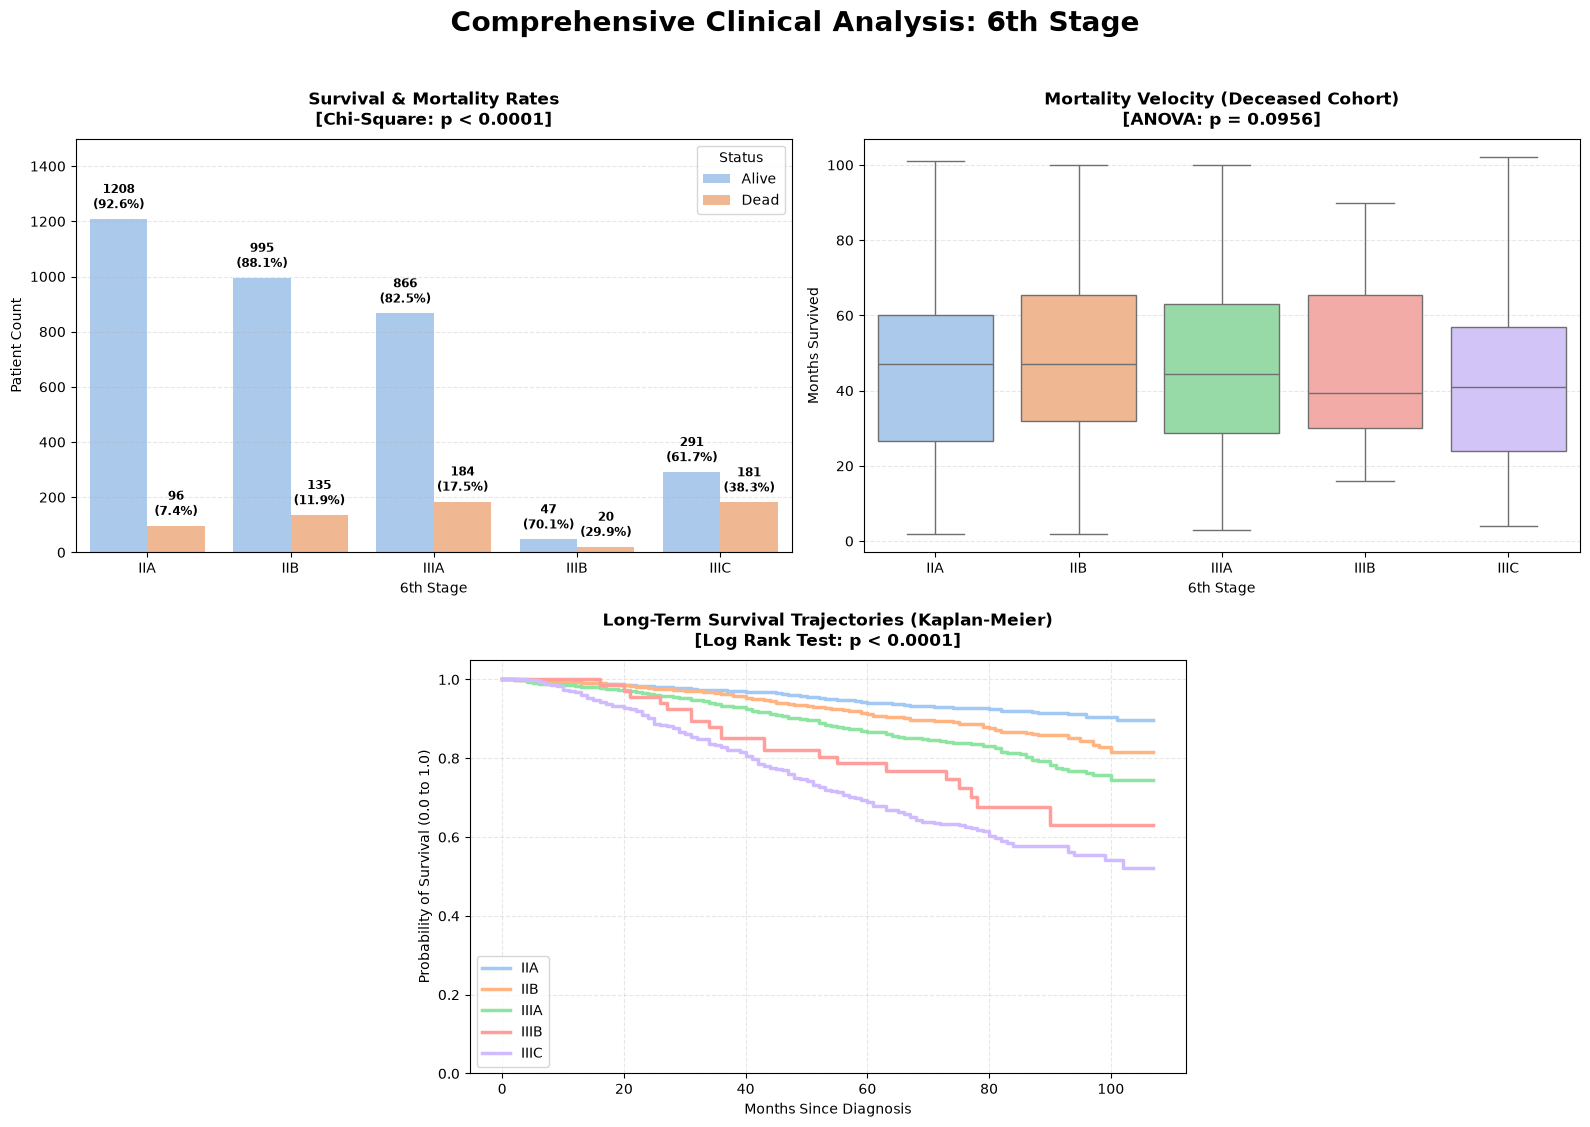

In [26]:
six_order = ['IIA','IIB', 'IIIA', 'IIIB', 'IIIC']
at.plot_comprehensive_analysis_dashboard('6th Stage', six_order, df)

**Results Interpretation:**

- Survival & Mortality Rates (p < 0.0001): There is a highly significant, stepwise disparity in overall mortality rates based on 6th Stage. Patients at Stage IIA demonstrate the lowest mortality rate (7.4%). As the stage advances, the mortality rate increases at each step, peaking at 38.3% for Stage IIIC.
- Survival Trajectories (p < 0.0001): The Kaplan-Meier curves beautifully illustrate this tiered prognostic decline. Each advancing stage corresponds to a distinctly lower, permanently separated survival trajectory. The Stage IIIC cohort experiences the steepest and most sustained drop in long-term survival probability.
- Mortality Velocity (p = 0.0956): ANOVA test for the mortality velocity fails to reach statistical significance. The high p-value indicates that within the deceased cohort, patients' 6th Stage does not statistically alter the timeline or velocity of their decline.

Therefore, 6th Stage is a highly statistically significant prognostic factor for overall survival likelihood. However, once the disease becomes terminal, it does not significantly alter the velocity or timeline of mortality.

(Note: The 'IIIB' cohort has a noticeably smaller sample size than the surrounding groups, meaning its specific metrics should be interpreted with standard clinical caution.)

#### **10. Grade** (Categorical factor)

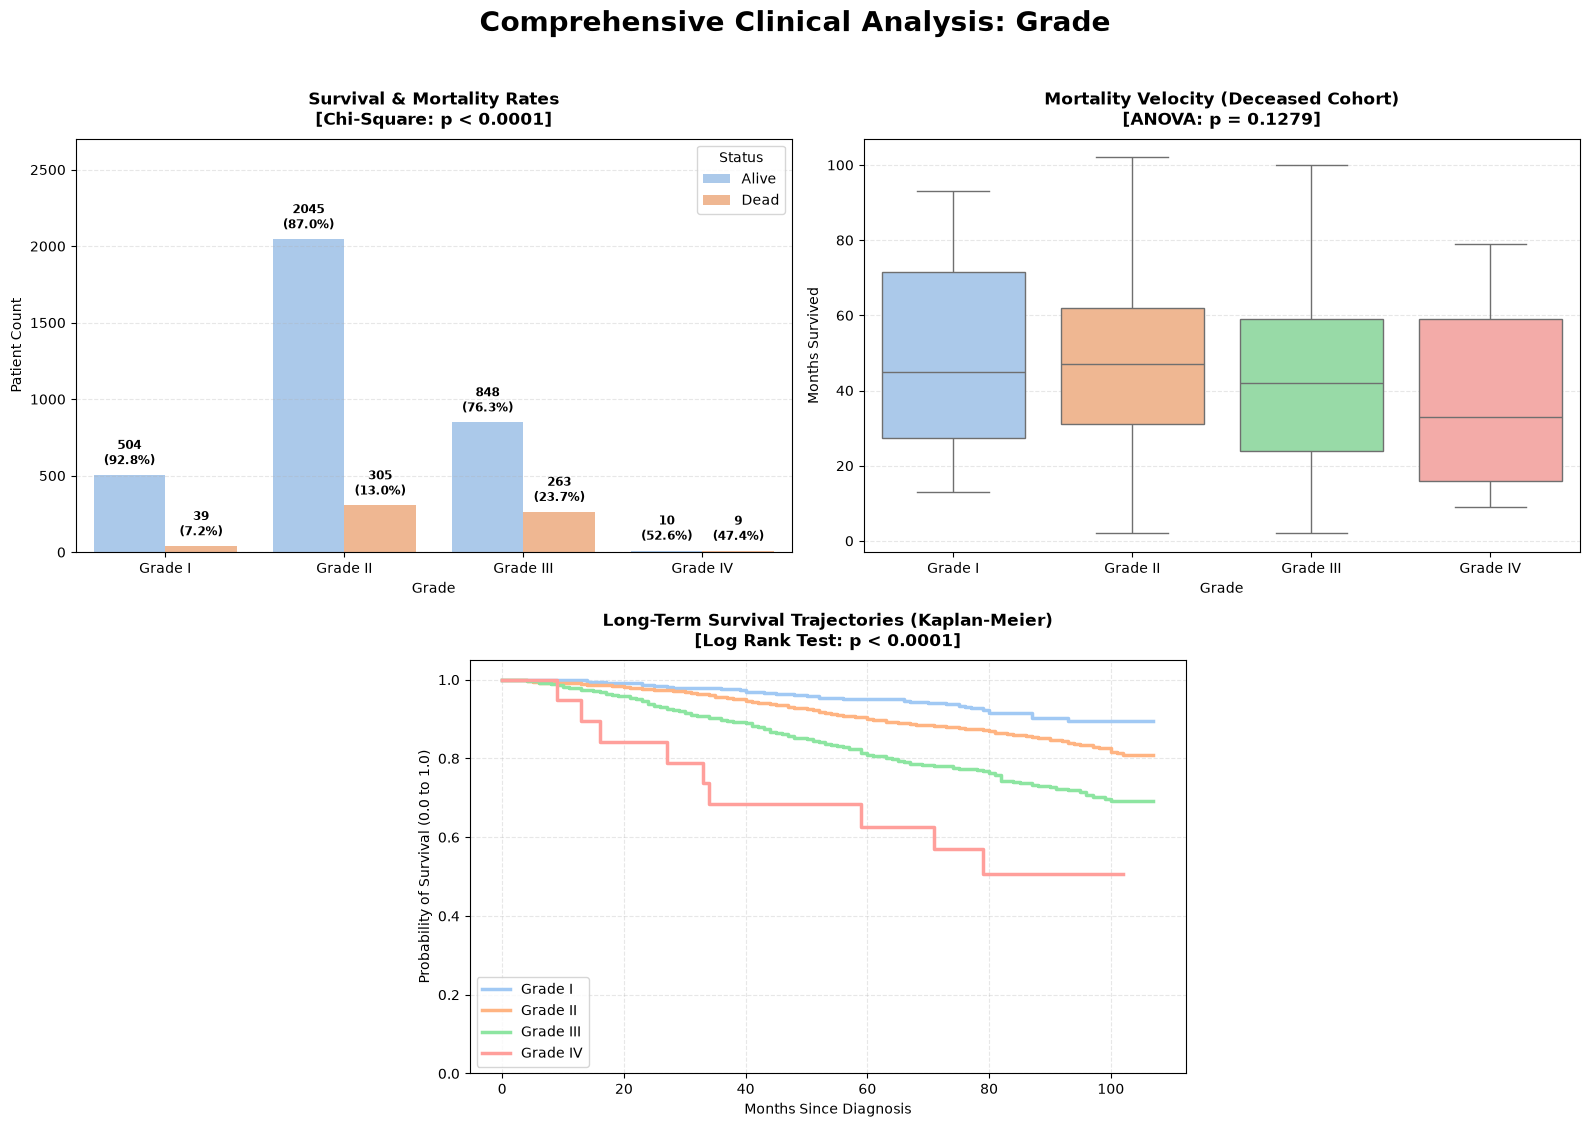

In [27]:
# Set up a dictionary to shorten the group name, where the 'Key' is the old name, and the 'Value' is the new name
replacements = {
    'Well Differentiated; Grade I': 'Grade I',
    'Moderately Differentiated; Grade II': 'Grade II',
    'Poorly Differentiated; Grade III': 'Grade III',
    'Undifferentiated; Anaplastic; Grade IV': 'Grade IV'
}

# Pass the dictionary into the replace function
df['Grade'] = df['Grade'].replace(replacements)

grade_order = ['Grade I', 'Grade II', 'Grade III','Grade IV']
at.plot_comprehensive_analysis_dashboard('Grade', grade_order, df)

**Results Interpretation:**

- Survival & Mortality Rates (p < 0.0001): There is a highly significant, stepwise disparity in overall mortality rates based on the grade of cancer. Patients at Grade I demonstrate the lowest mortality rate (7.2%). As the stage advances, the mortality rate increases at each step, peaking at 47.4% for Grade IV.
- Survival Trajectories (p < 0.0001): The Kaplan-Meier curves beautifully illustrate this tiered prognostic decline. Each advancing stage corresponds to a distinctly lower, permanently separated survival trajectory. The Grade IV cohort experiences the steepest and most sustained drop in long-term survival probability.
- Mortality Velocity (p = 0.1279): Similarly, the ANOVA test for the mortality velocity fails to reach statistical significance. The high p-value indicates that within the deceased cohort, the grade of cancer does not statistically alter the timeline or velocity of their decline.

Therefore, grade of cancer is a highly statistically significant prognostic factor for overall survival likelihood. However, once the disease becomes terminal, it does not significantly alter the velocity or timeline of mortality.

(Note: The 'Grade IV' cohort has a noticeably smaller sample size than the surrounding groups, meaning its specific metrics should be interpreted with standard clinical caution.)

#### **11. A Stage** (Categorical factor)

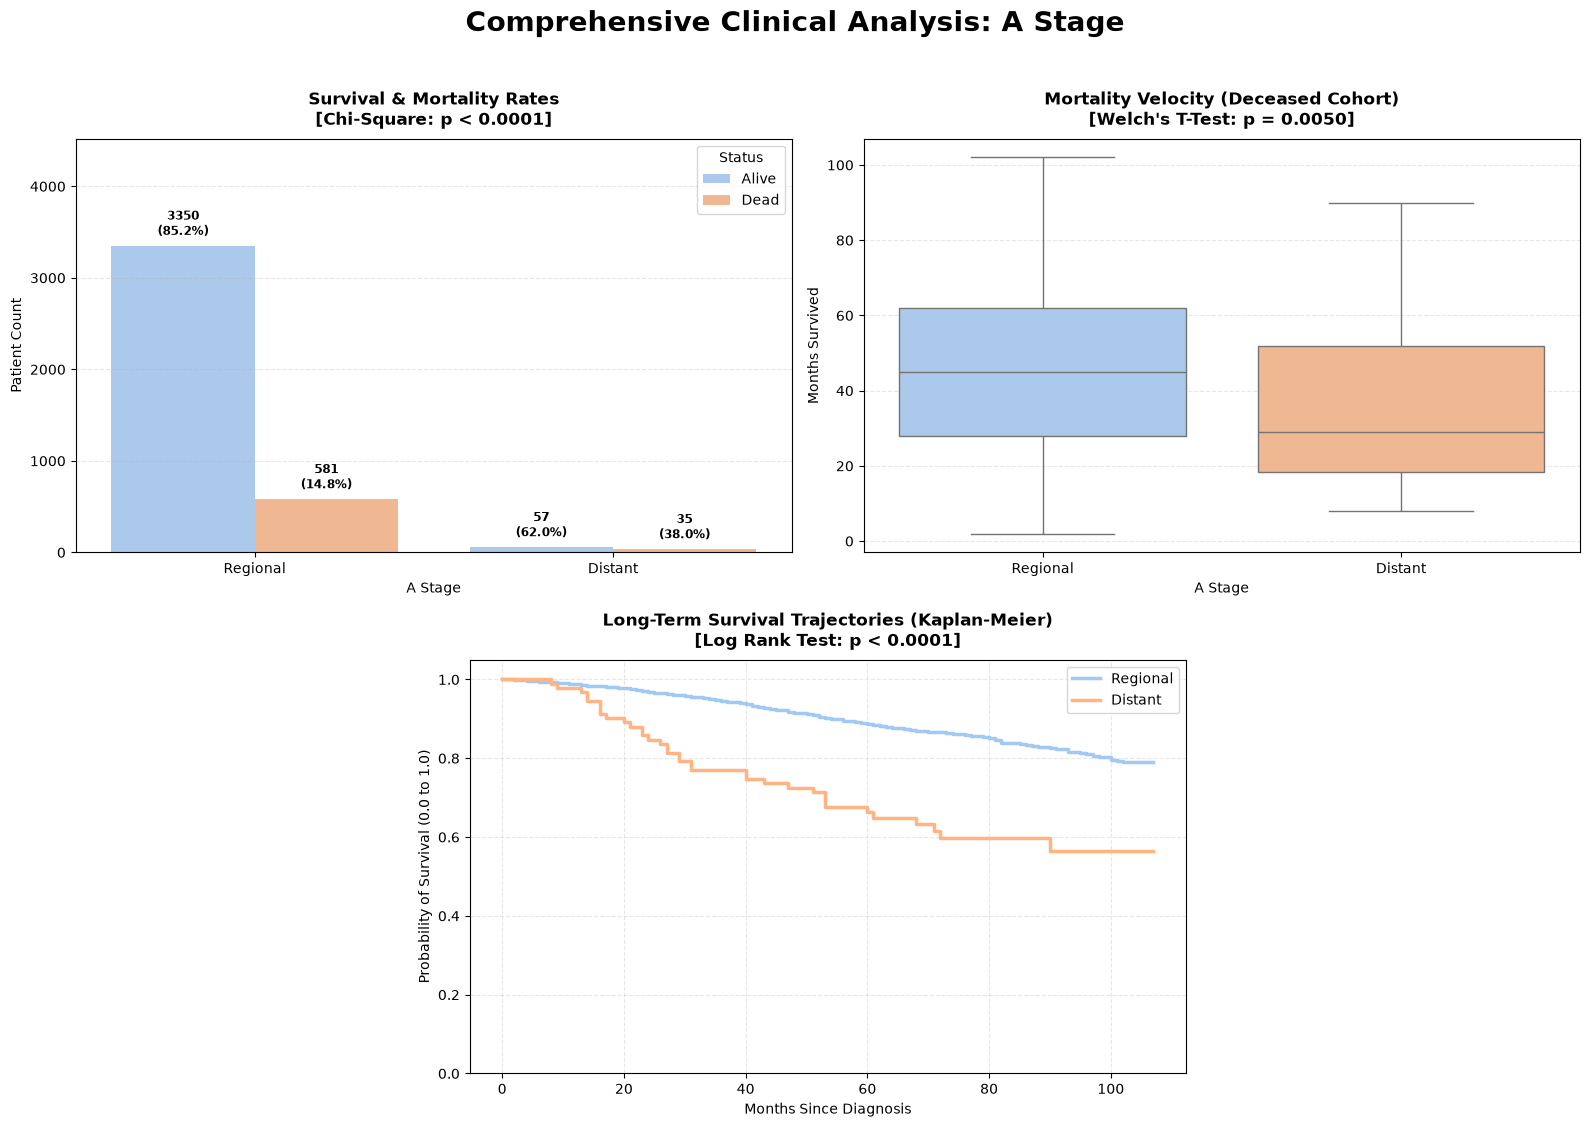

In [28]:
a_order = ['Regional', 'Distant']
at.plot_comprehensive_analysis_dashboard('A Stage', a_order, df)

**Results Interpretation:**

- Survival & Mortality Rates (p < 0.0001): There is a highly significant difference in overall mortality rates based on A Stage. Patients with "Regional" metastasis exhibit a baseline mortality rate of 14.8%. However, for patients presenting with "Distant" metastasis, the mortality rate skyrockets to 38.0%.
- Survival Trajectories (p < 0.0001): The Kaplan-Meier curves mathematically confirm this severe divergence. The Regional cohort maintains a relatively stable and high survival probability over time. In contrast, the Distant cohort experiences a sharp, sustained drop-off, visually representing the aggressive and lethal nature of systemic cancer spread.
- Mortality Velocity (p = 0.0050): Critically, the test for mortality velocity reached strong statistical significance. The median survival drops drastically from approximately 45 months for Regional patients to roughly 30 months for Distant patients. This proves that within the deceased cohort, systemic metastasis accelerates the timeline of terminal decline.

Therefore, A Stage (Metastasis) is an exceptionally powerful prognostic factor. It is highly statistically significant in predicting both the overall likelihood of mortality and the rapid velocity at which terminal mortality occurs.

(Note: The "Distant" cohort has a small sample size compared to the "Regional" cohort. The highly jagged, stepped nature of its Kaplan-Meier curve reflects this lower volume, but the statistical tests confirm the overall trend is mathematically genuine).

#### **12. Estrogen Status** (Categorical factor)

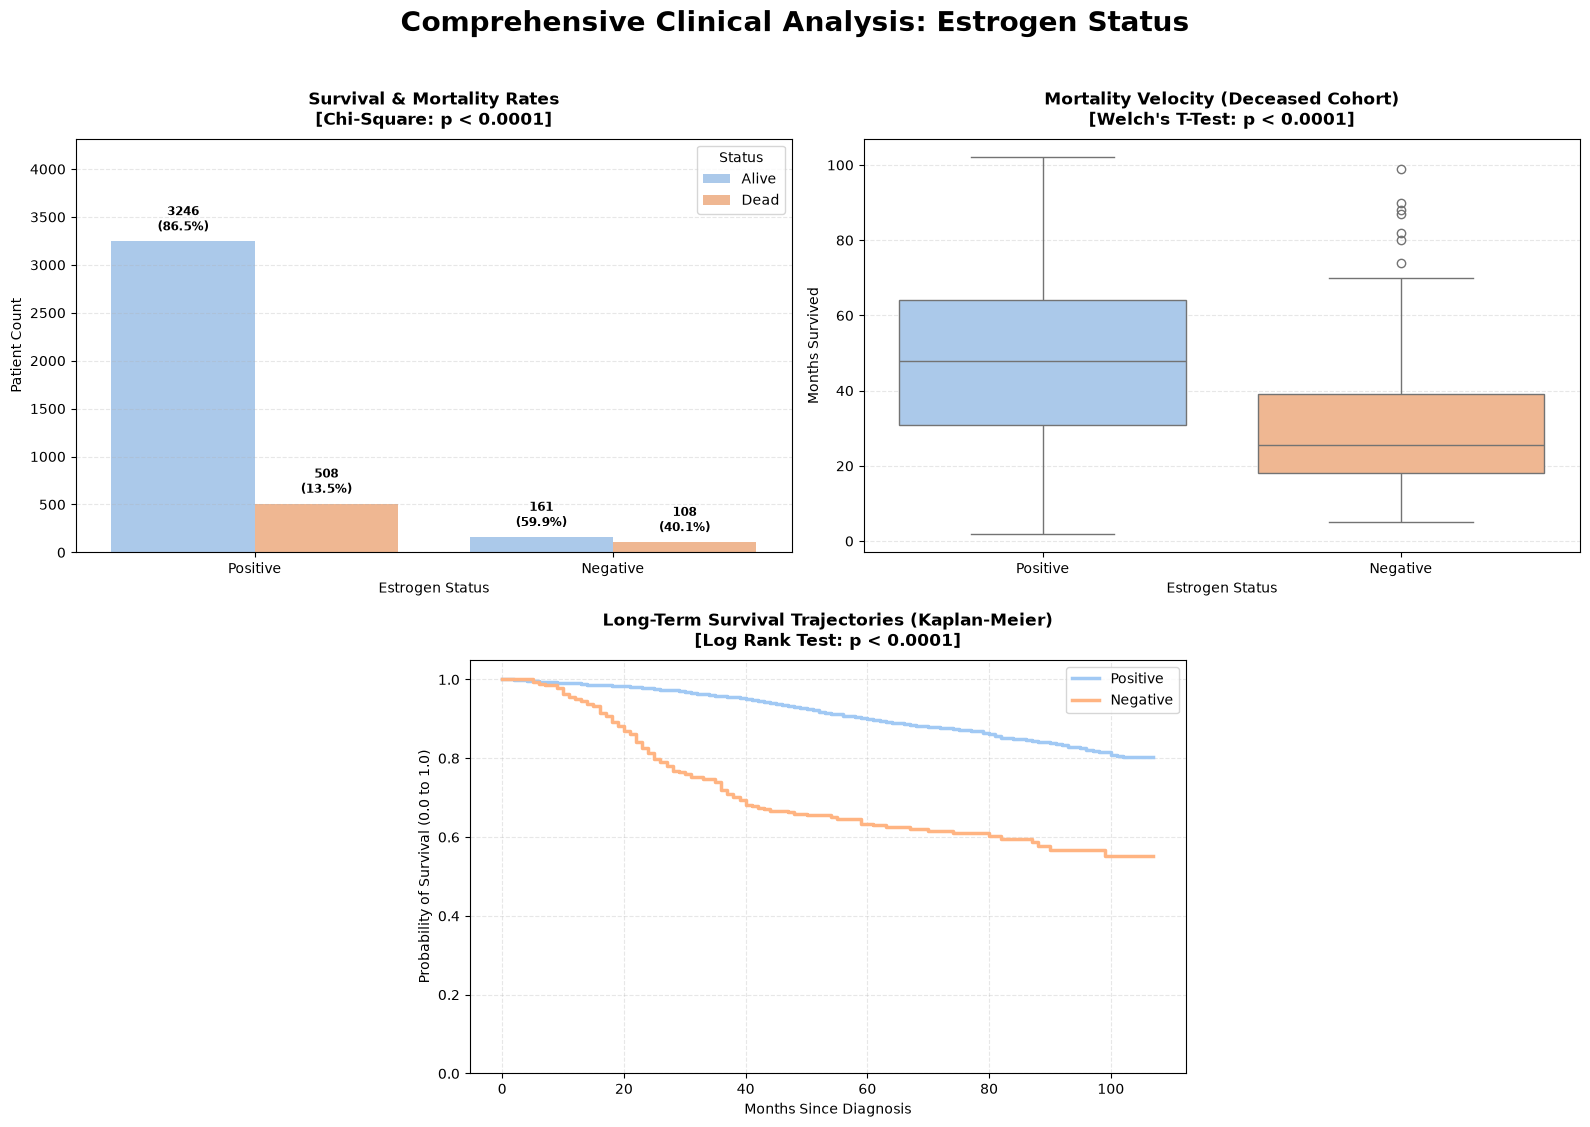

In [29]:
estrogen_order = ['Positive', 'Negative']
at.plot_comprehensive_analysis_dashboard('Estrogen Status', estrogen_order, df)

**Results Interpretation:**

- Survival & Mortality Rates (p < 0.0001): There is a highly significant difference in overall mortality rates based on estrogen receptor status. Patients with estrogen receptor-positive status exhibit a baseline mortality rate of 13.5%. However, for patients presenting with estrogen receptor-negative status, the mortality rate nearly triples, skyrocketing to 40.1%.
- Survival Trajectories (p < 0.0001): The Kaplan-Meier curves mathematically confirm this severe divergence. The Positive cohort maintains a relatively stable and high survival probability over time. In contrast, the Negative cohort experiences a sharp, sustained drop-off from the very beginning of the observation period.
- Mortality Velocity (p < 0.0001): Critically, the test for mortality velocity reached strong statistical significance. The median survival drops drastically from approximately 50 months for the Positive cohort to roughly 27 months for Negative cohort. This proves that within the deceased cohort, a negative estrogen receptor status accelerates the timeline of terminal decline.

Therefore, estrogen receptor status is an exceptionally powerful prognostic factor. A negative status is highly statistically significant in predicting both a massive increase in the overall likelihood of mortality and a highly accelerated velocity of decline.


#### **13. Progesterone Status** (Categorical factor)

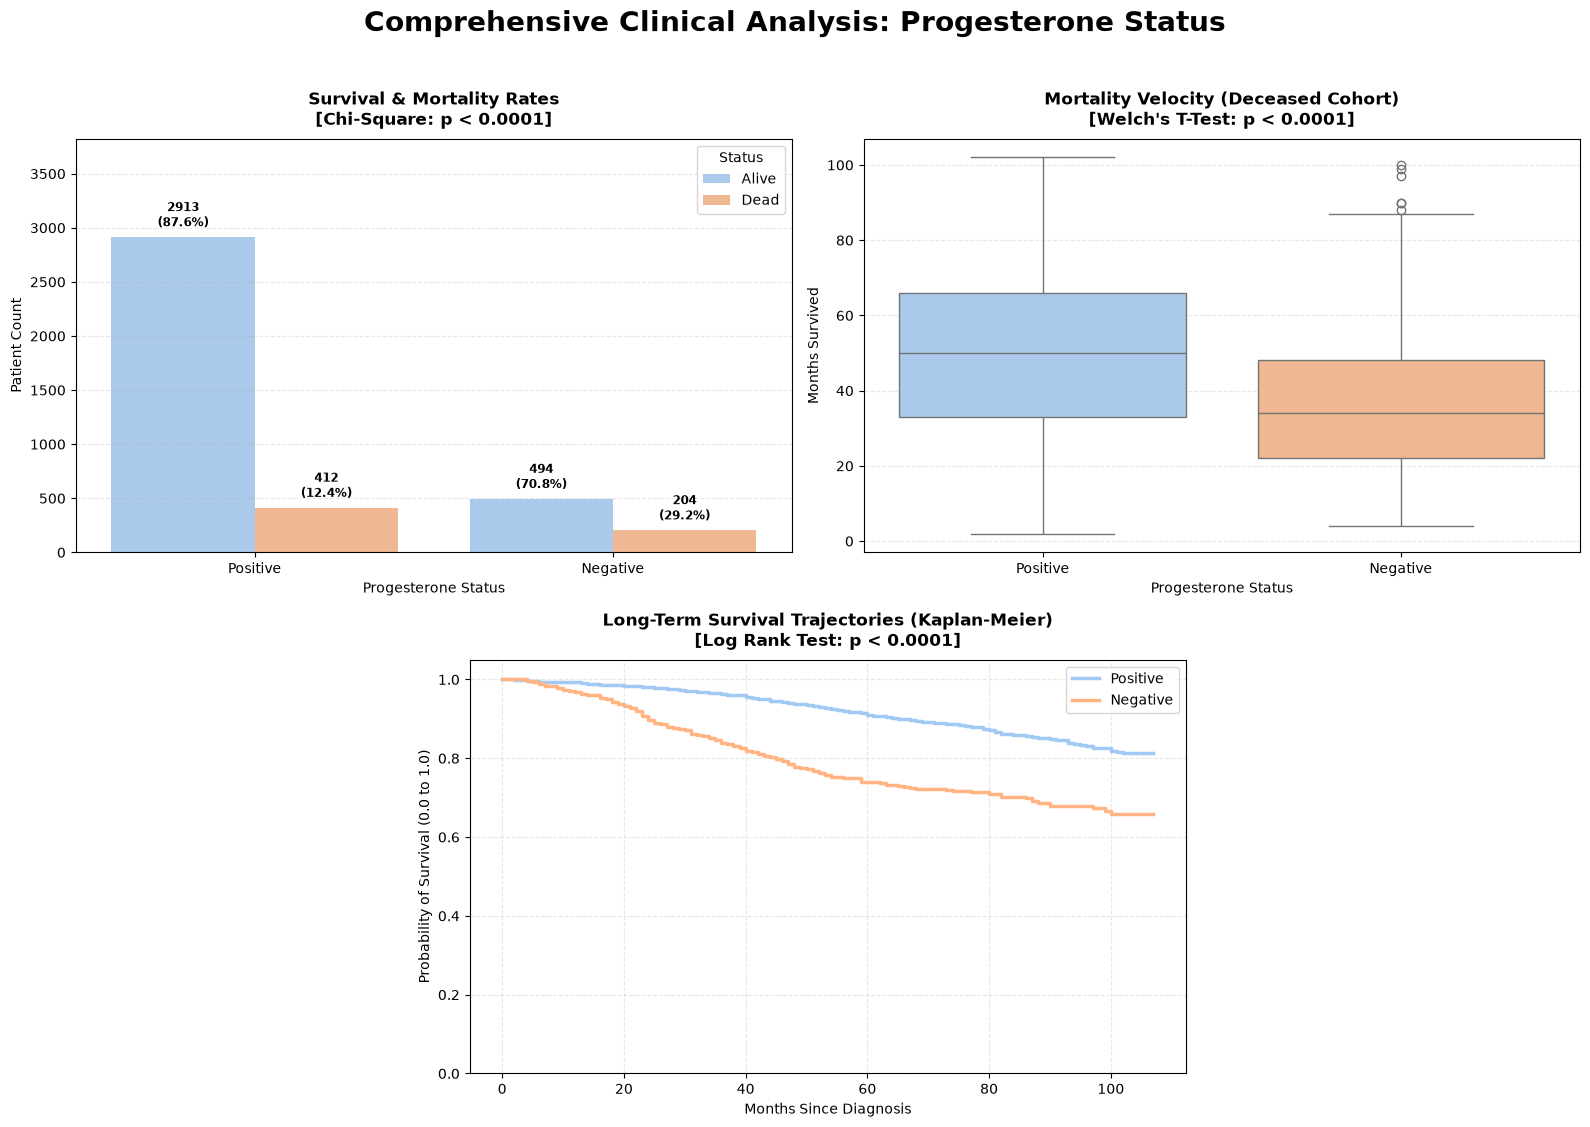

In [30]:
proges_order = ['Positive', 'Negative']
at.plot_comprehensive_analysis_dashboard('Progesterone Status', proges_order, df)

**Results Interpretation:**

- Survival & Mortality Rates (p < 0.0001): There is a highly significant difference in overall mortality rates based on progesterone receptor status. Patients with progesterone receptor-positive status exhibit a baseline mortality rate of 12.4%. However, for patients presenting with progesterone receptor-negative status, the mortality rate increases to 29.2%.
- Survival Trajectories (p < 0.0001): The Kaplan-Meier curves mathematically confirm this severe divergence. The Positive cohort maintains a relatively stable and high survival probability over time. In contrast, the Negative cohort experiences a sharp, sustained drop-off from the very beginning of the observation period.
- Mortality Velocity (p < 0.0001): Similar to "Estrogen Status", the test for mortality velocity reached strong statistical significance. The median survival drops drastically from approximately 50 months for the Positive cohort to roughly 35 months for Negative cohort. This proves that within the deceased cohort, a negative progesterone receptor status accelerates the timeline of terminal decline.

Therefore, progesterone receptor status is an exceptionally powerful prognostic factor, similar to estrogen receptor status. A negative status is highly statistically significant in predicting both a massive increase in the overall likelihood of mortality and a highly accelerated velocity of decline.
